In [421]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix,roc_curve,roc_auc_score

In [422]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [423]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [424]:
df.shape

(1470, 35)

In [425]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [426]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [427]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [428]:
df.nunique().sort_values().head(10)

Over18               1
StandardHours        1
EmployeeCount        1
Gender               2
Attrition            2
PerformanceRating    2
OverTime             2
MaritalStatus        3
Department           3
BusinessTravel       3
dtype: int64

# EDA

In [429]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [430]:
for col in df.select_dtypes(include='object'):
    print("\n",col)
    print(df[col].value_counts())


 Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

 BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

 Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

 EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

 Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

 JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

 MaritalStatus
MaritalStatus
Married  

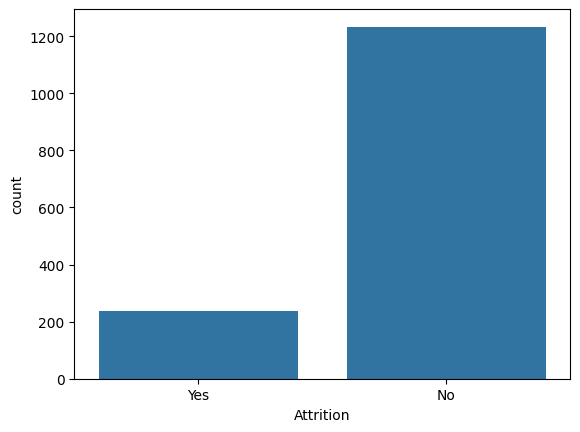

In [431]:
sns.countplot(x='Attrition',data=df)
plt.show()

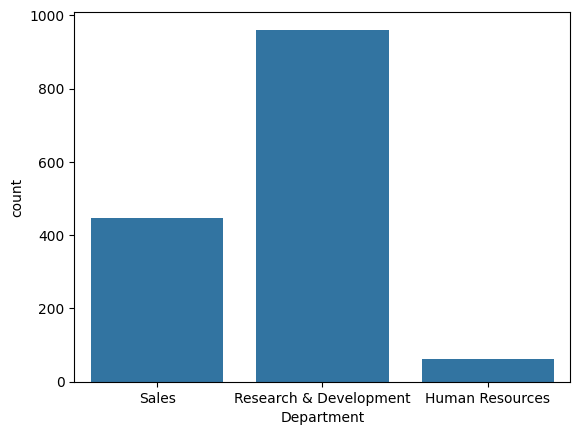

In [432]:
sns.countplot(x='Department',data=df)
plt.show()


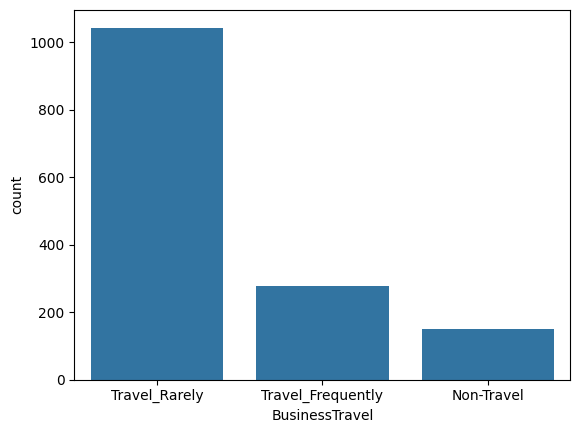

In [433]:
sns.countplot(x='BusinessTravel',data=df)
plt.show()

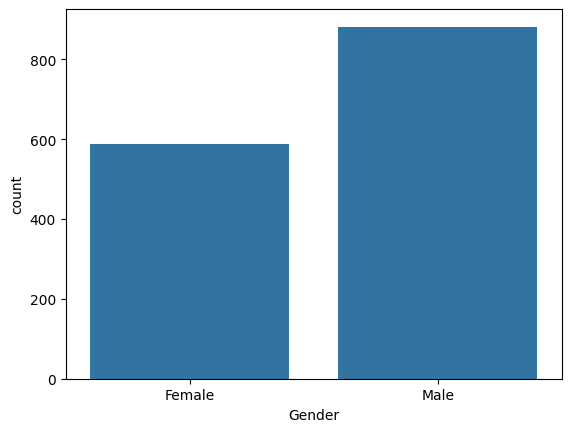

In [434]:
sns.countplot(x='Gender',data=df)
plt.show()

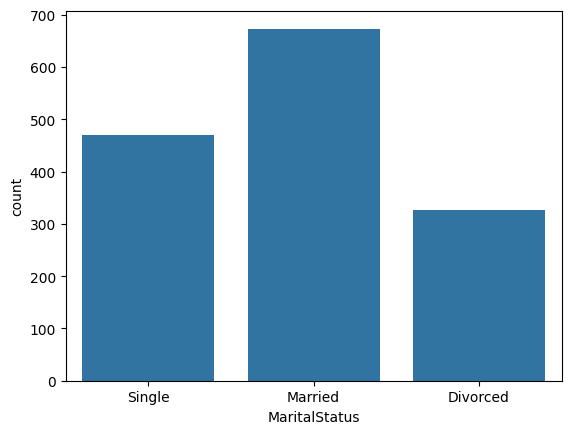

In [435]:
sns.countplot(x='MaritalStatus',data=df)
plt.show()

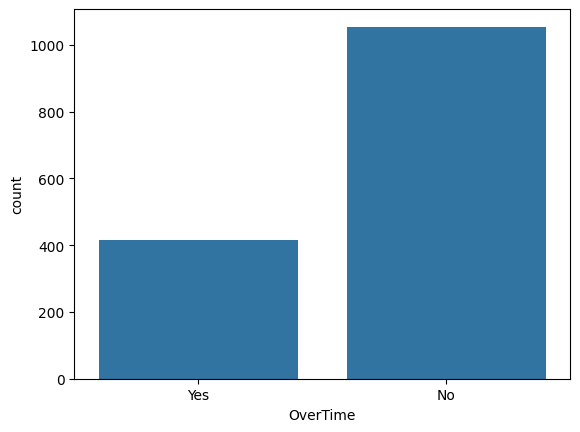

In [436]:
sns.countplot(x='OverTime',data=df)
plt.show()

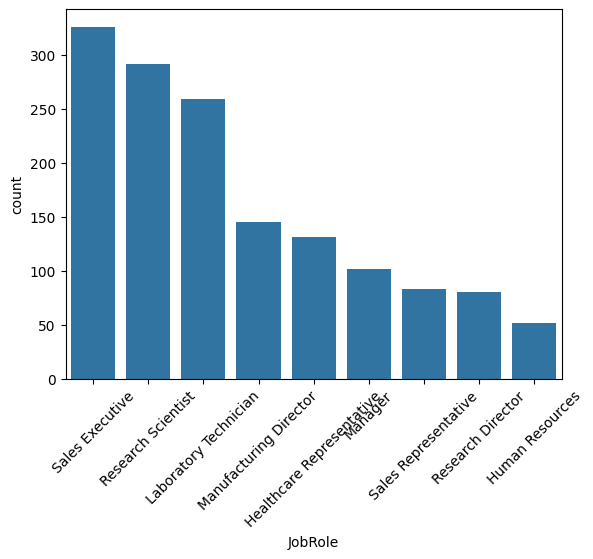

In [437]:
sns.countplot(x='JobRole',data=df)
plt.xticks(rotation=45)
plt.show()

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Life Sciences'),
  Text(1, 0, 'Other'),
  Text(2, 0, 'Medical'),
  Text(3, 0, 'Marketing'),
  Text(4, 0, 'Technical Degree'),
  Text(5, 0, 'Human Resources')])

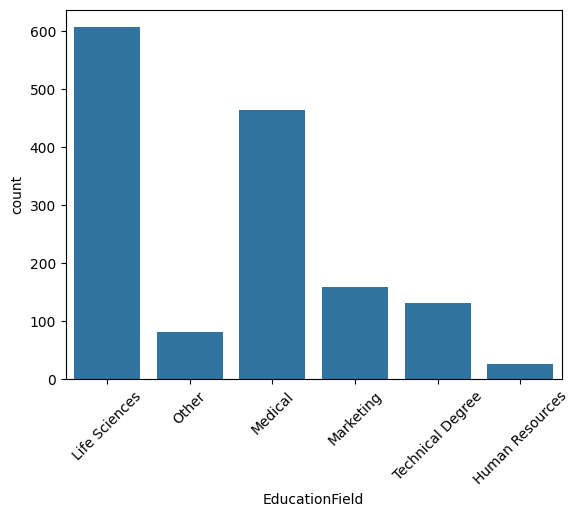

In [438]:
sns.countplot(x="EducationField",data=df)
plt.xticks(rotation=45)

<Axes: xlabel='Age', ylabel='Count'>

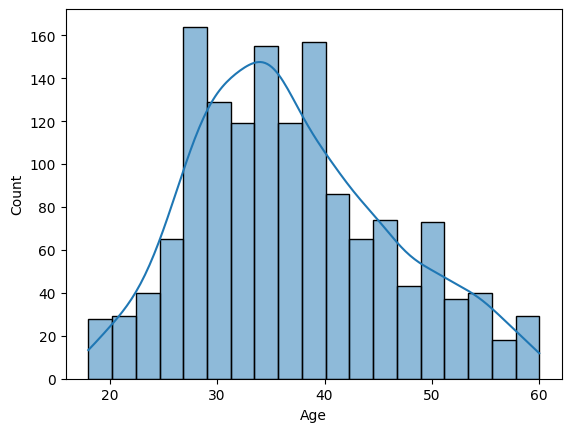

In [439]:
sns.histplot(x='Age',data=df,kde=True)


<Axes: xlabel='MonthlyIncome', ylabel='Count'>

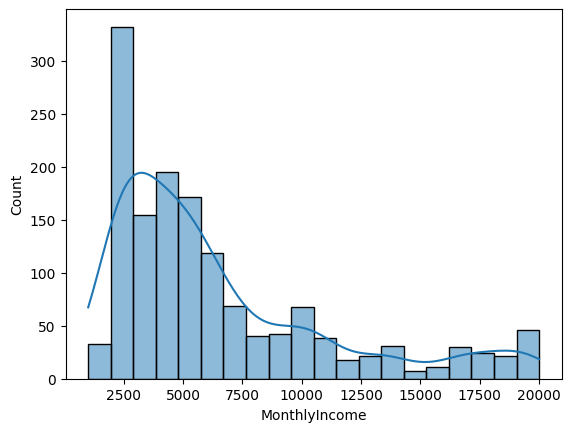

In [440]:
sns.histplot(x='MonthlyIncome',data=df,kde=True)

<Axes: xlabel='DistanceFromHome', ylabel='Count'>

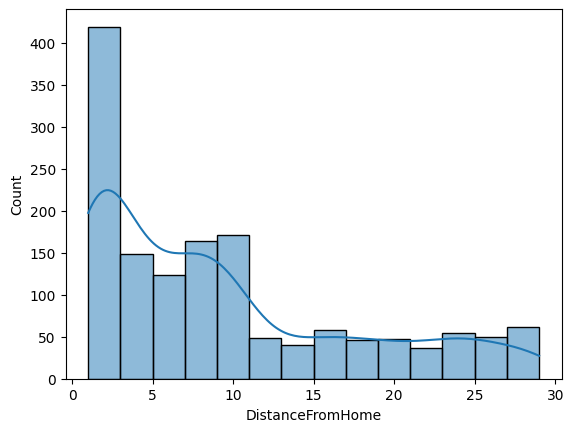

In [441]:
sns.histplot(x='DistanceFromHome',data=df,kde=True)

<Axes: xlabel='TotalWorkingYears', ylabel='Count'>

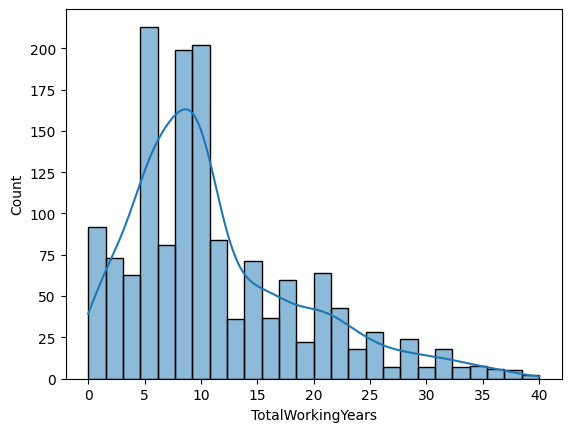

In [442]:
sns.histplot(x='TotalWorkingYears',data=df,kde=True)

<Axes: xlabel='YearsAtCompany', ylabel='Count'>

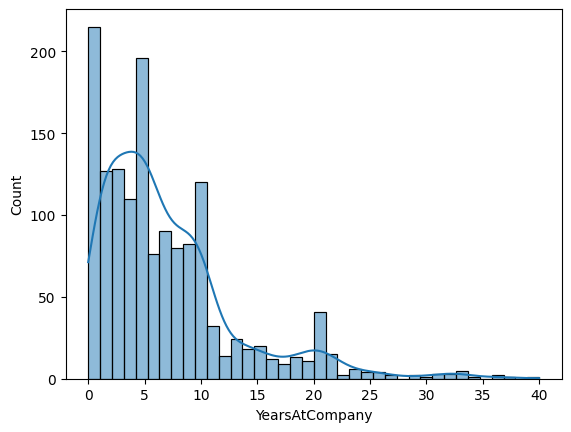

In [443]:
sns.histplot(x='YearsAtCompany',data=df,kde=True)

In [444]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')*100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


In [445]:
pd.crosstab(df['JobRole'], df['Attrition'], normalize='index')*100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


In [446]:
pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index')*100


Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


In [447]:
pd.crosstab(df['BusinessTravel'], df['Attrition'], normalize='index')*100

Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


In [448]:
pd.crosstab(df['Department'], df['Attrition'], normalize='index')*100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

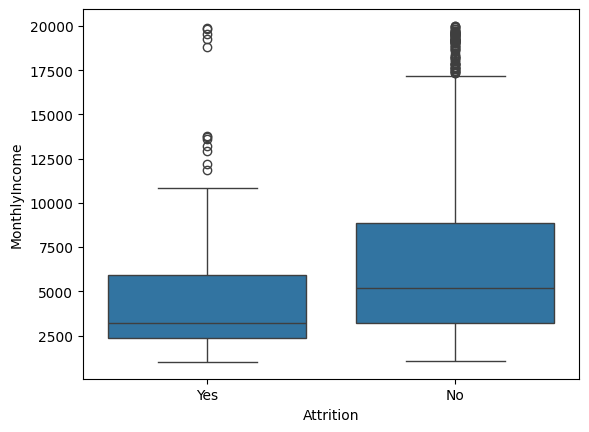

In [449]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

<Axes: xlabel='Age'>

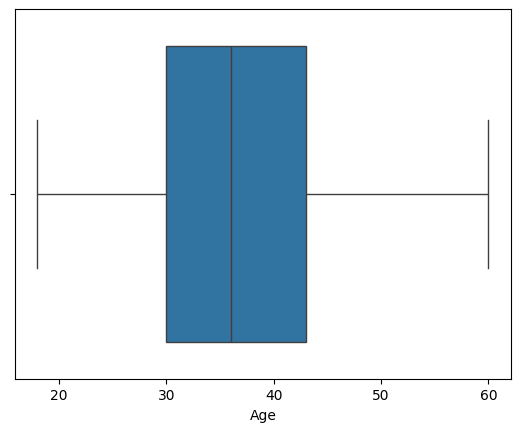

In [450]:
sns.boxplot(x='Age',data=df)

<Axes: xlabel='MonthlyIncome'>

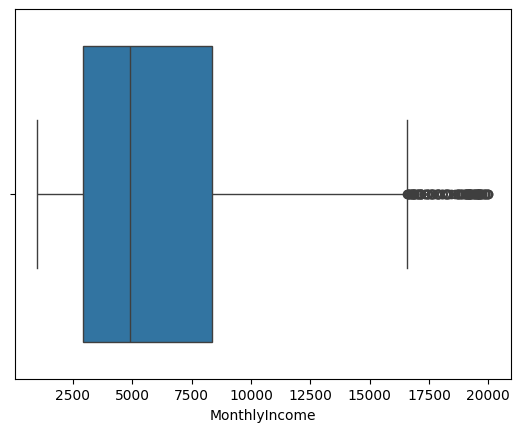

In [451]:
sns.boxplot(x="MonthlyIncome",data=df)

<Axes: xlabel='DistanceFromHome'>

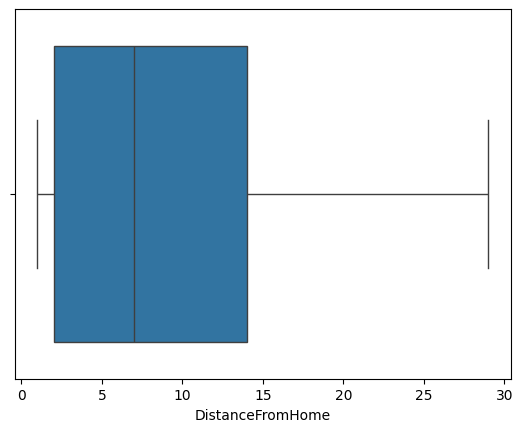

In [452]:
sns.boxplot(x="DistanceFromHome",data=df)

<Axes: xlabel='TotalWorkingYears'>

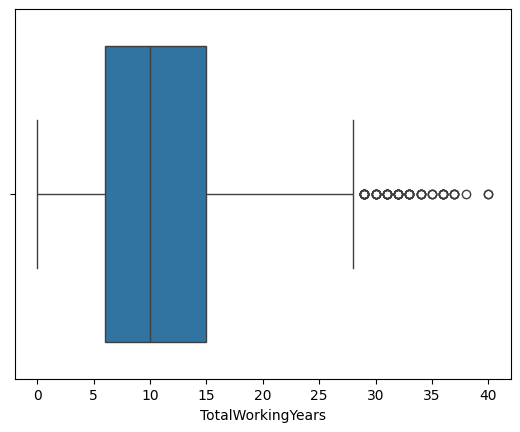

In [453]:
sns.boxplot(x='TotalWorkingYears',data=df)

<Axes: xlabel='YearsAtCompany'>

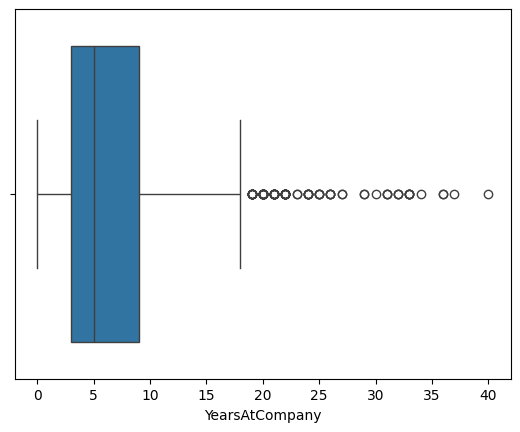

In [454]:
sns.boxplot(x='YearsAtCompany',data=df)

# Checking null and duplicated values

In [455]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [456]:
df.duplicated().sum()

np.int64(0)

# Dropping Columns that are not important 

In [457]:
col_to_drop=df[['Education','EmployeeCount','Over18','StandardHours','EmployeeNumber','PerformanceRating','HourlyRate','MonthlyRate','PercentSalaryHike']]

In [458]:
df.drop(columns=col_to_drop,inplace=True)

In [459]:
df.shape

(1470, 26)

# Feature Enginnering
- Creating usefull features from  current features

In [460]:
df['YearSincePromotionRatio']=df['YearsSinceLastPromotion']/(df['YearsAtCompany']+1)

In [461]:
df['YearsWithManagerRatio']=df['YearsWithCurrManager']/(df['YearsAtCompany']+1)

In [462]:
df['AverageYearsperCompany']=df['TotalWorkingYears']/(df['NumCompaniesWorked']+1)

In [463]:
df['IncomePerJoblevel']=df["MonthlyIncome"]/df['JobLevel']

In [464]:
df['AgeGroup']=pd.cut(df['Age'],bins=[18,25,35,45,60],labels=['18-25','26-35','36-45','46-60'],include_lowest=True)

In [465]:
df['TenureGroup']=pd.cut(df['YearsAtCompany'],bins=[0,2,5,10,df['YearsAtCompany'].max()],labels=['0-2','3-5','6-10','10+'],include_lowest=True)

In [466]:
df[['Age', 'AgeGroup', 'YearsAtCompany', 'TenureGroup']].head()

,Age,AgeGroup,YearsAtCompany,TenureGroup
0,41,36-45,6,6-10
1,49,46-60,10,6-10
2,37,36-45,0,0-2
3,33,26-35,8,6-10
4,27,26-35,2,0-2


In [467]:
df[['YearSincePromotionRatio',
    'YearsWithManagerRatio',
    'AverageYearsperCompany',
    'IncomePerJoblevel']].describe()

,YearSincePromotionRatio,YearsWithManagerRatio,AverageYearsperCompany,IncomePerJoblevel
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.236458,0.465510,4.193478,2973.800986
std,0.269358,0.276763,4.035504,770.640517
min,0.000000,0.000000,0.000000,1009.000000
25%,0.000000,0.285714,1.600000,2394.125000
50%,0.142857,0.500000,3.000000,2856.500000
75%,0.428571,0.666667,5.000000,3478.833333
max,0.916667,0.894737,38.000000,4999.000000


In [468]:
df.corr(numeric_only=True)

,Age,DailyRate,DistanceFromHome,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,RelationshipSatisfaction,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,YearSincePromotionRatio,YearsWithManagerRatio,AverageYearsperCompany,IncomePerJoblevel
Age,1.000000,0.010661,-0.001686,0.010146,0.029820,0.509604,-0.004892,0.497855,0.299635,0.053535,...,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089,0.086028,0.036476,0.287096,0.275880
DailyRate,0.010661,1.000000,-0.004985,0.018355,0.046135,0.002966,0.030571,0.007707,0.038153,0.007846,...,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363,-0.022231,0.022307,-0.020103,0.024014
DistanceFromHome,-0.001686,-0.004985,1.000000,-0.016075,0.008783,0.005303,-0.003669,-0.017014,-0.029251,0.006557,...,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406,0.006481,0.005839,0.007236,-0.037132
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,1.000000,-0.008278,0.001212,-0.006784,-0.006259,0.012594,0.007665,...,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999,0.021511,0.005075,-0.000330,-0.036422
JobInvolvement,0.029820,0.046135,0.008783,-0.008278,1.000000,-0.012630,-0.021476,-0.015271,0.015012,0.034297,...,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976,-0.002068,0.077435,-0.002027,-0.014837
JobLevel,0.509604,0.002966,0.005303,0.001212,-0.012630,1.000000,-0.001944,0.950300,0.142501,0.021642,...,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281,0.111766,0.060412,0.472119,0.428363
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.006784,-0.021476,-0.001944,1.000000,-0.007157,-0.055699,-0.012454,...,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656,-0.000405,-0.013278,0.021996,-0.013062
MonthlyIncome,0.497855,0.007707,-0.017014,-0.006259,-0.015271,0.950300,-0.007157,1.000000,0.149515,0.025873,...,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079,0.114987,0.042966,0.459222,0.654670
NumCompaniesWorked,0.299635,0.038153,-0.029251,0.012594,0.015012,0.142501,-0.055699,0.149515,1.000000,0.052733,...,-0.066054,-0.008366,-0.118421,-0.090754,-0.036814,-0.110319,0.004687,-0.044506,-0.417690,0.125898
RelationshipSatisfaction,0.053535,0.007846,0.006557,0.007665,0.034297,0.021642,-0.012454,0.025873,0.052733,1.000000,...,0.002497,0.019604,0.019367,-0.015123,0.033493,-0.000867,0.023941,0.003272,-0.027297,0.005227


In [469]:
df['Attrition']=df['Attrition'].map({'No':0,'Yes':1})

In [470]:
df.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)

Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
YearSincePromotionRatio     0.010412
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
IncomePerJoblevel          -0.113963
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
AverageYearsperCompany     -0.150500
YearsWithManagerRatio      -0.153259
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: Attrition, dtype: float64

# Preprocessing

In [471]:
x=df.drop('Attrition',axis=1)
y=df['Attrition']

In [472]:
num_col=x.select_dtypes(include=['int64','float64']).columns

In [473]:
cat_col=x.select_dtypes(include=['object','category']).columns

In [474]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_col),
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_col)
    ]
)

In [475]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [476]:
x_train.shape

(1176, 31)

In [477]:
x_test.shape

(294, 31)

In [478]:
len(num_col)

22

In [479]:
len(cat_col)

9

# Build Model

In [480]:
model=Pipeline([
    ('Preprocessing',preprocessor),
    ('classifier',LogisticRegression(max_iter=1000,class_weight='balanced'))
])

In [481]:
model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Age','BusinessTravel','DailyRate',...,'IncomePerJoblevel','AgeGroup', 'TenureGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [482]:
y_pred=model.predict(x_test)

In [483]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7721088435374149
Precision: 0.3780487804878049
Recall   : 0.6595744680851063
F1 Score : 0.4806201550387597


In [484]:
print("confusion metrics: ",confusion_matrix(y_test,y_pred))

confusion metrics:  [[196  51]
 [ 16  31]]


# Business Insights

1. Employees who work overtime are significantly more likely to leave the organization.

2. Employees who travel frequently show higher attrition rates compared to non-traveling employees.

3. Single employees have higher attrition rates than married employees.

4. Employees with lower monthly income tend to leave more frequently.

5. Sales-related job roles and departments exhibit higher attrition rates.

6. Employees with fewer total working years are more likely to leave the company.

7. Employees who remain longer with the same manager tend to have lower attrition rates.

# Recommendations

1. Monitor employees working excessive overtime and improve workload distribution.

2. Review travel policies and employee well-being for frequent travelers.

3. Improve retention strategies for early-career employees.

4. Reassess compensation and growth opportunities for lower-income employees.

5. Focus retention efforts on high-risk departments and job roles, especially Sales.


In [485]:
y_prob = model.predict_proba(x_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8118701007838746


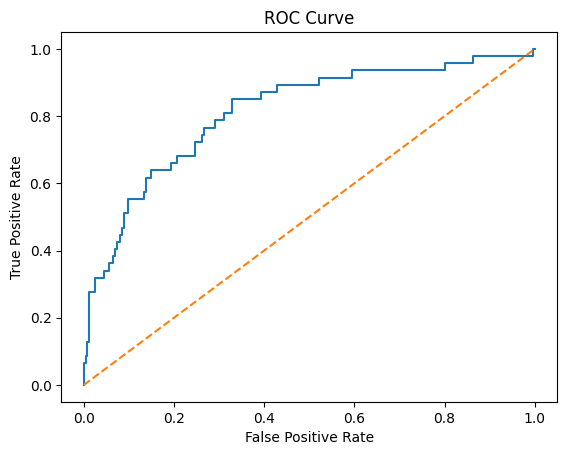

In [486]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [487]:
y_prob = model.predict_proba(x_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8118701007838746


In [491]:
print(x.shape)
print(x.columns.tolist())

(1470, 31)
['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'YearSincePromotionRatio', 'YearsWithManagerRatio', 'AverageYearsperCompany', 'IncomePerJoblevel', 'AgeGroup', 'TenureGroup']


In [492]:
import joblib

joblib.dump(model, "attrition_model.pkl")

['attrition_model.pkl']

In [493]:
loaded_model = joblib.load("attrition_model.pkl")

In [494]:
loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Age','BusinessTravel','DailyRate',...,'IncomePerJoblevel','AgeGroup', 'TenureGroup']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=